In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/business_partners/part-20251119-133435-168.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/sales_order_headers/part-20251119-133429-440.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/billing_document_items/part-20251119-133432-233.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/billing_document_items/part-20251119-133432-978.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/product_descriptions/part-20251119-133438-991.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/product_descriptions/part-20251119-133438-106.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/product_plants/part-20251119-133439-232.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/product_plants/part-20251119-133439-814.jsonl
/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/product_plants/part-20251119-133439-488.jsonl
/kaggle/input/datasets/devya

In [2]:
!pip install langgraph langchain langchain-openai langchain-community langchain-anthropic networkx neo4j pandas streamlit plotly pyvis graphviz duckdb polars streamlit-chat openai anthropic python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━

In [3]:
# Cell 1: Install + Imports (Run First)

import pandas as pd
import polars as pl
import duckdb
import json
import os
from pathlib import Path
from typing import Dict, List, Any
import networkx as nx
from pyvis.network import Network
import streamlit as st
from IPython.display import display, HTML, clear_output
print("All dependencies installed!") 

All dependencies installed!


In [4]:
!pip install -U langgraph-cli langgraph dev 

ERROR: Ignored the following versions that require a different python version: 0.1.0 Requires-Python <3.12,>=3.9.0; 0.1.1 Requires-Python <3.12,>=3.9.0; 0.1.2 Requires-Python <3.12,>=3.9.0; 0.1.3 Requires-Python <3.12,>=3.9.0; 0.1.4 Requires-Python <3.12,>=3.9.0; 0.1.5 Requires-Python <3.12,>=3.9.0; 0.1.6 Requires-Python <3.12,>=3.9.0; 0.1.7 Requires-Python <3.12,>=3.9.0
ERROR: Could not find a version that satisfies the requirement dev (from versions: none)
ERROR: No matching distribution found for dev


In [5]:
!pip install groq 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 2.8 MB/s eta 0:00:00a 0:00:01


In [6]:
!pip install sentence-transformers 

In [7]:
!pip install -qU langgraph langchain-openai langchain-community networkx pyvis streamlit plotly duckdb pandas pyarrow neo4j langchain-groq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 66.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 54.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.2.10 requires langgraph<1.1.0,>=1.0.8, but you have langgraph 1.1.3 which is incompatible.


In [8]:
!pip install -q langgraph langchain langchain-groq groq networkx pyvis sentence-transformers 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 3.3 MB/s eta 0:00:00a 0:00:01


Groq model: openai/gpt-oss-20b  |  connected: True


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  SAP O2C LANGGRAPH MULTI-AGENT SYSTEM  v3
  Model : openai/gpt-oss-20b
  Fixes : robust router | order# extract | force viz | raw query

Loading SAP O2C tables ...
  OK  sales_order_headers                                     100 rows x 24 cols
  OK  sales_order_items                                       167 rows x 13 cols
  OK  sales_order_schedule_lines                              179 rows x 6 cols
  OK  outbound_delivery_headers                                86 rows x 13 cols
  OK  outbound_delivery_items                                 137 rows x 11 cols
  OK  billing_document_headers                                163 rows x 14 cols
  OK  billing_document_items                                  245 rows x 9 cols
  OK  billing_document_cancellations                           80 rows x 14 cols
  OK  payments_accounts_receivable                            120 rows x 23 cols
  OK  journal_entry_items_accounts_receivable                 123 rows x 22 cols
  OK  business_partners   

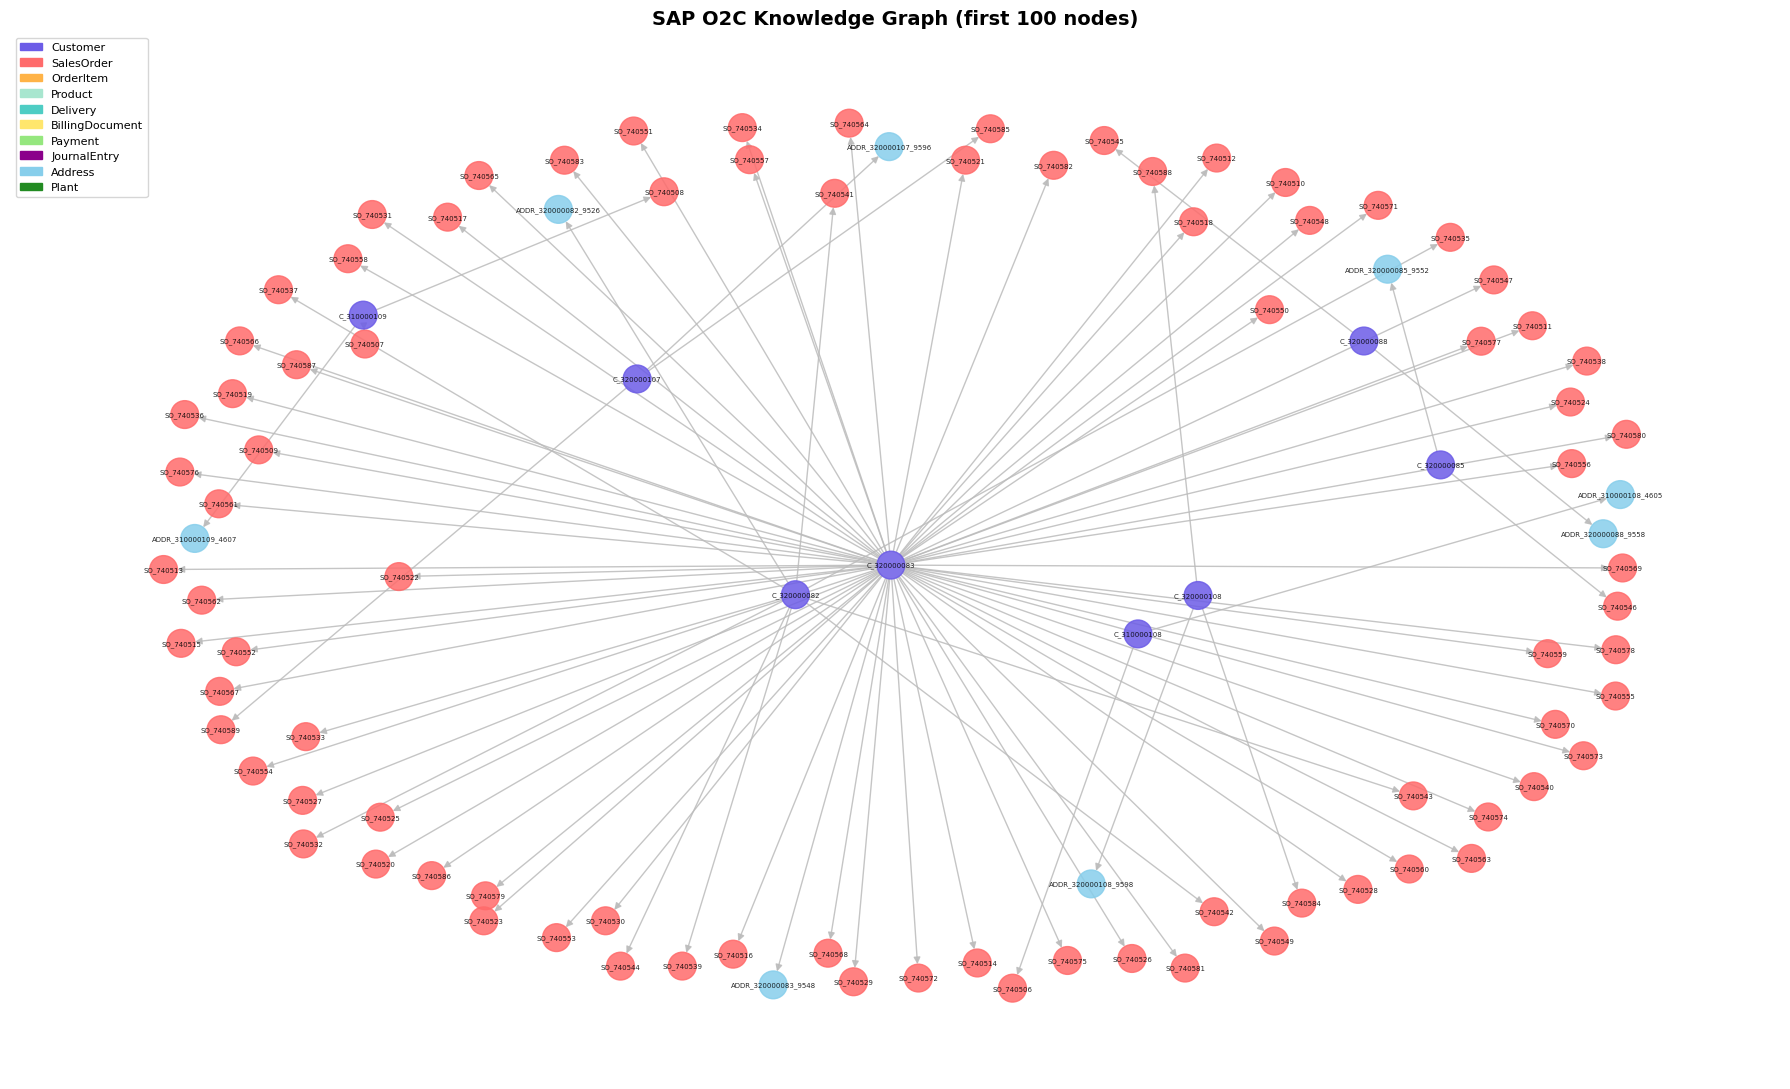

Saved: sap_graph.png
Compiling LangGraph pipeline ...
Pipeline ready.


  DEMO QUERIES

Query: Give me overall graph statistics and node counts.
--------------------------------------------------
🤖 
  Intent : stats
  Answer :



⚠️  No highlight nodes from LLM for intent 'stats'. Generating fallback...

📊 Auto-visualizing 5 nodes for intent 'stats': ['C_310000108', 'SO_740506', 'DEL_80738076']...


Graph saved: graph_highlight.html
  Highlighted nodes: ['C_310000108', 'SO_740506', 'DEL_80738076', 'BIL_90504248', 'PAY_9400000220']

Query: Which products have the highest number of billing documents?
--------------------------------------------------
🤖 **KEY FINDING:**  
Two products have the highest number of billing documents, each with 11 unique billing documents: FACESERUM 30ML VIT C (S8907367008620) and SUNSCREEN GEL SPF50‑PA+++ 50ML (S8907367039280).

**DATA:**  

| Material ID        | Product Name                     | Unique Billing Docs |
|--------------------|----------------------------------|---------------------|
| S8907367008620     | FACESERUM 30ML VIT C             | 11                  |
| S8907367039280     | SUNSCREEN GEL SPF50‑PA+++ 50ML   | 11                  |

**FLOW/NODES:**  
P_S8907367008620 → P_S8907367039280

**HIGHLIGHT:**  
["P_S8907367008620", "P_S8907367039280"]
  Intent : product_billing
  Answer :
**KEY FINDING:**  
Two products have the highest n

Graph saved: graph_highlight.html
  Highlighted nodes: ['P_S8907367008620', 'P_S8907367039280']

Query: Trace the full O2C flow for sales order 740506.
--------------------------------------------------
🤖 **KEY FINDING:** Sales order 740506 has been delivered but not
  Intent : trace_order
  Answer :
**KEY FINDING:** Sales order 740506 has been delivered but not


⚠️  No highlight nodes from LLM for intent 'trace_order'. Generating fallback...

📊 Auto-visualizing 2 nodes for intent 'trace_order': ['SO_740506', 'DEL_80737721']...


Graph saved: graph_highlight.html
  Highlighted nodes: ['SO_740506', 'DEL_80737721']

Query: Show all sales orders that were delivered but never billed.
--------------------------------------------------
🤖 
  Intent : broken_flows
  Answer :



⚠️  No highlight nodes from LLM for intent 'broken_flows'. Generating fallback...

📊 Auto-visualizing 6 nodes for intent 'broken_flows': ['SO_740506', 'SO_740507', 'SO_740508']...


Graph saved: graph_highlight.html
  Highlighted nodes: ['SO_740506', 'SO_740507', 'SO_740508', 'SO_740509', 'SO_740510']

Query: How many billing documents have been cancelled and what is the total value?
--------------------------------------------------
🤖 **KEY FINDING:** No cancellation data is available in the provided statistics, so the number of cancelled billing documents and their total value cannot be determined.  

**DATA:**  
```json
{
  "total_nodes": 849,
  "total_edges": 785,
  "node_types": {
    "Customer": 8,
    "Address": 8,
    "SalesOrder": 100,
    "OrderItem": 167,
    "Product": 69,
    "Delivery": 86,
    "Plant": 5,
    "BillingDocument": 163,
    "Payment": 120,
    "JournalEntry": 123
  },
  "so_count": 100,
  "delivery_count": 86,
  "billing_count": 163,
  "payment_count": 120,
  "customer_count": 8,
  "product_count": 69,
  "journal_count": 123,
  "address_count": 8,
  "plant_count": 5
}
```

**FLOW
  Intent : stats
  Answer :
**KEY FINDING:** No cancellat

...

🔍 Semantic context (not sent to router): ['PLANT_KA05', 'P_B8907367037842', 'P_S8907367004448']

Agent [off_topic].

Out of scope. I handle SAP O2C data only.
Ask about: orders, deliveries, billing, payments, customers, products.
💾 Memory: 5 turn(s) stored

-----------------------------------------------------------------


You:  tell me about india IPL


🔍 Semantic context (not sent to router): ['P_S8907367001867', 'ADDR_320000082_9526', 'P_S8907367013587']

Agent [off_topic].

Out of scope. I handle SAP O2C data only.
Ask about: orders, deliveries, billing, payments, customers, products.
💾 Memory: 6 turn(s) stored

-----------------------------------------------------------------


You:  exit


Goodbye.


In [10]:
"""
SAP O2C LangGraph Multi-Agent System 
Model: openai/gpt-oss-20b via Groq
"""

import os, re, json, warnings
from pathlib import Path
from typing import TypedDict, List, Dict, Any, Optional
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

from groq import Groq
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq

# ── Semantic search ─────────────────────────────────────────────────────
try:
    from sentence_transformers import SentenceTransformer
    HAS_ST = True
except ImportError:
    HAS_ST = False
    print("sentence-transformers not installed; semantic search disabled.")

try:
    from pyvis.network import Network
    HAS_PYVIS = True
except ImportError:
    HAS_PYVIS = False

try:
    from IPython.display import display, HTML
    HAS_DISPLAY = True
except ImportError:
    HAS_DISPLAY = False

# =============================================================================
# GROQ SETUP  —  model: openai/gpt-oss-20b
# =============================================================================
GROQ_API_KEY = os.environ.get(
    "GROQ_API_KEY",
    "write api key")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

GROQ_MODEL = "openai/gpt-oss-20b"

groq_client = Groq(api_key=GROQ_API_KEY)

# ── Streaming LLM ───────────────────────────────────────────────────────────
def call_llm_stream(system_prompt: str, user_prompt: str, max_tokens: int = 1200) -> str:
    """Streaming LLM responses — tokens printed as they arrive."""
    try:
        stream = groq_client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user",   "content": user_prompt},
            ],
            temperature=0,
            max_tokens=max_tokens,
            stream=True,
        )
        full_response = ""
        print("🤖 ", end="", flush=True)
        for chunk in stream:
            if chunk.choices[0].delta.content:
                content = chunk.choices[0].delta.content
                full_response += content
                print(content, end="", flush=True)
        print()
        return full_response
    except Exception as e:
        return f"[Stream error: {e}]"

def _call_llm_once(system_prompt: str, user_prompt: str, max_tokens: int = 200) -> str:
    try:
        completion = groq_client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user",   "content": user_prompt},
            ],
            temperature=0,
            max_tokens=max_tokens,
        )
        return completion.choices[0].message.content
    except Exception as e:
        return f"[LLM unavailable: {e}]"

_test  = _call_llm_once("You are a test assistant.", "Reply with: OK")
HAS_LLM = not _test.startswith("[LLM unavailable")
print(f"Groq model: {GROQ_MODEL}  |  connected: {HAS_LLM}")
if not HAS_LLM:
    print(f"  Detail: {_test}")

# =============================================================================
# CONVERSATION MEMORY
# =============================================================================
CONVERSATION_HISTORY: List[Dict] = []
MAX_HISTORY = 5

# =============================================================================
# SEMANTIC SEARCH  (global state)
# =============================================================================
NODE_EMBEDDINGS: Dict[str, Dict] = {}
semantic_model = SentenceTransformer("all-MiniLM-L6-v2") if HAS_ST else None

def build_semantic_index(graph: "SAPO2CGraph") -> np.ndarray:
    """Embed all node descriptions and store in NODE_EMBEDDINGS."""
    global NODE_EMBEDDINGS
    if not HAS_ST:
        return np.array([])
    NODE_EMBEDDINGS = {}
    for node_id, node_data in graph.G.nodes(data=True):
        text = (f"{node_data.get('type', '')}: {node_id} | " +
                " | ".join([f"{k}:{v}" for k, v in node_data.items()
                             if k not in ("type", "color")][:4]))
        emb = semantic_model.encode([text])[0]
        NODE_EMBEDDINGS[node_id] = {"text": text, "embedding": emb}
    print(f"Semantic index built: {len(NODE_EMBEDDINGS):,} nodes indexed.")
    return np.array([v["embedding"] for v in NODE_EMBEDDINGS.values()])

def semantic_search(query: str, top_k: int = 5) -> List[str]:
    """Return top-k node IDs most semantically similar to query."""
    if not HAS_ST or not NODE_EMBEDDINGS:
        return []
    query_emb = semantic_model.encode([query])[0]
    sims = [
        (node_id, float(np.dot(query_emb, data["embedding"])), data["text"][:100])
        for node_id, data in NODE_EMBEDDINGS.items()
    ]
    sims.sort(key=lambda x: x[1], reverse=True)
    return [s[0] for s in sims[:top_k]]

# =============================================================================
# EVALUATION CRITERIA
# =============================================================================
EVAL_NODES: List[str] = []

# =============================================================================
# DATA LOADING
# =============================================================================
BASE = "/kaggle/input/datasets/devyaniseth/sap-order/sap-o2c-data/"

def load_table(name: str) -> pd.DataFrame:
    folder = Path(BASE) / name
    parts  = sorted(folder.glob("*.jsonl")) if folder.exists() else []
    if not parts:
        return pd.DataFrame()
    frames = []
    for p in parts:
        try:
            df = pd.read_json(p, lines=True)
            df.columns = (df.columns.str.strip()
                          .str.replace(r'([A-Z])', r'_\1', regex=True)
                          .str.lstrip('_').str.lower()
                          .str.replace(r'\s+', '_', regex=True))
            frames.append(df)
        except Exception as e:
            print(f"  ! {p.name}: {e}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_all_tables() -> Dict[str, pd.DataFrame]:
    NAMES = [
        "sales_order_headers", "sales_order_items", "sales_order_schedule_lines",
        "outbound_delivery_headers", "outbound_delivery_items",
        "billing_document_headers", "billing_document_items",
        "billing_document_cancellations", "payments_accounts_receivable",
        "journal_entry_items_accounts_receivable",
        "business_partners", "business_partner_addresses",
        "customer_company_assignments", "customer_sales_area_assignments",
        "products", "product_descriptions", "product_plants",
        "product_storage_locations", "plants",
    ]
    print("Loading SAP O2C tables ...")
    data = {}
    for n in NAMES:
        df = load_table(n)
        if not df.empty:
            data[n] = df
            print(f"  OK  {n:50s}  {len(df):>7,} rows x {df.shape[1]} cols")
        else:
            print(f"  --  {n}")
    print()
    return data

def _numeric(df, *cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

def _dates(df, *cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# =============================================================================
# KNOWLEDGE GRAPH
# =============================================================================
NODE_COLORS = {
    "Customer":        "#6C5CE7",
    "SalesOrder":      "#FF6B6B",
    "OrderItem":       "#FFB347",
    "Product":         "#A8E6CF",
    "Delivery":        "#4ECDC4",
    "BillingDocument": "#FFE66D",
    "Payment":         "#95E77E",
    "JournalEntry":    "#8B008B",
    "Address":         "#87CEEB",
    "Plant":           "#228B22",
}

class SAPO2CGraph:
    def __init__(self, data: Dict[str, pd.DataFrame]):
        self.G     = nx.MultiDiGraph()
        self.data  = data
        self._raw: Dict[str, pd.DataFrame] = {}
        self._stats: Dict = {}
        self._build()

    def _add_node(self, nid, **attrs):
        self.G.add_node(str(nid), **attrs)

    def _add_edge(self, s, t, label, **attrs):
        self.G.add_edge(str(s), str(t), label=label, **attrs)

    def _build(self):
        d = self.data

        so_hdr  = d.get("sales_order_headers",           pd.DataFrame()).copy()
        so_itm  = d.get("sales_order_items",              pd.DataFrame()).copy()
        del_hdr = d.get("outbound_delivery_headers",      pd.DataFrame()).copy()
        del_itm = d.get("outbound_delivery_items",        pd.DataFrame()).copy()
        bil_hdr = d.get("billing_document_headers",       pd.DataFrame()).copy()
        bil_itm = d.get("billing_document_items",         pd.DataFrame()).copy()
        bil_can = d.get("billing_document_cancellations", pd.DataFrame()).copy()
        pay     = d.get("payments_accounts_receivable",   pd.DataFrame()).copy()
        bp      = d.get("business_partners",              pd.DataFrame()).copy()
        pdesc   = d.get("product_descriptions",           pd.DataFrame()).copy()

        _numeric(so_hdr,  "total_net_amount")
        _numeric(so_itm,  "net_amount", "requested_quantity")
        _numeric(bil_hdr, "total_net_amount")
        _numeric(bil_itm, "net_amount", "billing_quantity")
        _numeric(bil_can, "total_net_amount")
        _numeric(pay,     "amount_in_transaction_currency")
        _numeric(del_itm, "actual_delivery_quantity")

        _dates(so_hdr,  "creation_date", "requested_delivery_date")
        _dates(del_hdr, "actual_goods_movement_date", "creation_date")
        _dates(bil_hdr, "billing_document_date", "creation_date")
        _dates(pay,     "clearing_date", "posting_date")
        _dates(bil_can, "billing_document_date")

        self._raw = dict(so_hdr=so_hdr, so_itm=so_itm,
                         del_hdr=del_hdr, del_itm=del_itm,
                         bil_hdr=bil_hdr, bil_itm=bil_itm,
                         bil_can=bil_can, pay=pay, bp=bp, pdesc=pdesc)

        name_col = next((c for c in ["business_partner_full_name",
                                      "organization_bp_name1"]
                          if c in bp.columns), None)
        bp_name  = bp.set_index("customer")[name_col].to_dict() if name_col else {}

        desc_col = next((c for c in pdesc.columns
                          if c not in ["product", "language"]), None)
        prod_map = pdesc.set_index("product")[desc_col].to_dict() if desc_col else {}

        cancelled_docs = set(
            bil_can["billing_document"].astype(str)
            if "billing_document" in bil_can.columns else [])

        del_hdr_cols = list(del_hdr.columns)
        del_itm_cols = list(del_itm.columns)

        if ("delivery_document" in del_itm_cols and
                "actual_goods_movement_date" in del_hdr_cols and
                "delivery_document" in del_hdr_cols):
            del_merged = del_itm.merge(
                del_hdr[["delivery_document", "actual_goods_movement_date"]],
                on="delivery_document", how="left")
            gi_by_so = (del_merged.groupby("reference_sd_document")
                        ["actual_goods_movement_date"].min().to_dict())
        else:
            gi_by_so = {}

        # ── Customers ─────────────────────────────────────────────────────────
        if not bp.empty and "customer" in bp.columns:
            for _, row in bp.iterrows():
                cid = str(row["customer"])
                self._add_node(f"C_{cid}", type="Customer",
                               customer_id=cid,
                               name=bp_name.get(row["customer"], cid),
                               color=NODE_COLORS["Customer"])

        # ── Addresses ─────────────────────────────────────────────────────────
        addr = d.get("business_partner_addresses", pd.DataFrame()).copy()
        if not addr.empty and "business_partner" in addr.columns:
            for _, row in addr.head(20).iterrows():
                bp_id   = str(row.get("business_partner", ""))
                addr_id = str(row.get("address_id", ""))
                akey    = f"ADDR_{bp_id}_{addr_id}"
                self._add_node(akey, type="Address",
                               business_partner=bp_id,
                               city=row.get("city_name", ""),
                               country=row.get("country", ""),
                               street=row.get("street_name", ""),
                               color=NODE_COLORS["Address"])
                ckey = f"C_{bp_id}"
                if ckey in self.G:
                    self._add_edge(ckey, akey, "HAS_ADDRESS")

        # ── Sales Orders ──────────────────────────────────────────────────────
        if not so_hdr.empty:
            for _, row in so_hdr.iterrows():
                soid = str(row["sales_order"])
                self._add_node(f"SO_{soid}", type="SalesOrder",
                               sales_order=soid,
                               amount=row.get("total_net_amount", 0),
                               customer=str(row.get("sold_to_party", "")),
                               creation_date=str(row.get("creation_date", ""))[:10],
                               req_delivery=str(row.get("requested_delivery_date", ""))[:10],
                               delivery_status=str(row.get("overall_delivery_status", "")),
                               billing_status=str(row.get("overall_ord_reltd_billg_status", "")),
                               color=NODE_COLORS["SalesOrder"])
                ckey = f"C_{row.get('sold_to_party', '')}"
                if ckey in self.G:
                    self._add_edge(ckey, f"SO_{soid}", "PLACED_ORDER")

        # ── Order Items + Products ─────────────────────────────────────────────
        if not so_itm.empty:
            for _, row in so_itm.iterrows():
                soid = str(row["sales_order"])
                item = str(row.get("sales_order_item", ""))
                mat  = str(row.get("material", ""))
                ikey = f"SOI_{soid}_{item}"
                self._add_node(ikey, type="OrderItem",
                               sales_order=soid, item=item, material=mat,
                               qty=row.get("requested_quantity", 0),
                               amount=row.get("net_amount", 0),
                               color=NODE_COLORS["OrderItem"])
                if f"SO_{soid}" in self.G:
                    self._add_edge(f"SO_{soid}", ikey, "HAS_ITEM")
                pkey = f"P_{mat}"
                if pkey not in self.G:
                    self._add_node(pkey, type="Product", product=mat,
                                   name=prod_map.get(mat, mat),
                                   color=NODE_COLORS["Product"])
                self._add_edge(ikey, pkey, "REFERENCES_PRODUCT")

        # ── Deliveries ────────────────────────────────────────────────────────
        plants_df = d.get("plants", pd.DataFrame())

        if not del_itm.empty and "reference_sd_document" in del_itm.columns:
            seen_del = set()
            for _, row in del_itm.iterrows():
                doc  = str(row.get("delivery_document", ""))
                soid = str(row.get("reference_sd_document", ""))
                dkey = f"DEL_{doc}"
                gi   = gi_by_so.get(soid, pd.NaT)
                if dkey not in seen_del:
                    shipping_point = ""
                    if (not del_hdr.empty and
                            "delivery_document" in del_hdr.columns and
                            "shipping_point" in del_hdr.columns):
                        hdr_match = del_hdr[del_hdr["delivery_document"].astype(str) == doc]
                        if not hdr_match.empty:
                            shipping_point = str(hdr_match.iloc[0].get("shipping_point", ""))

                    self._add_node(dkey, type="Delivery",
                                   delivery_doc=doc,
                                   gi_date=str(gi)[:10] if pd.notna(gi) else "pending",
                                   shipping_point=shipping_point,
                                   color=NODE_COLORS["Delivery"])
                    seen_del.add(dkey)

                    if shipping_point:
                        plant_key = f"PLANT_{shipping_point}"
                        if plant_key not in self.G and not plants_df.empty:
                            plant_match = plants_df[
                                plants_df["plant"].astype(str) == shipping_point]
                            if not plant_match.empty:
                                p_row = plant_match.iloc[0]
                                self._add_node(plant_key, type="Plant",
                                               plant=p_row.get("plant", ""),
                                               name=p_row.get("plant_name", ""),
                                               color=NODE_COLORS["Plant"])
                        if plant_key in self.G:
                            self._add_edge(dkey, plant_key, "SHIPS_FROM")

                sokey = f"SO_{soid}"
                if sokey in self.G:
                    self._add_edge(sokey, dkey, "HAS_DELIVERY")

        # ── Billing Documents ─────────────────────────────────────────────────
        if not bil_hdr.empty:
            for _, row in bil_hdr.iterrows():
                bdoc = str(row.get("billing_document", ""))
                bkey = f"BIL_{bdoc}"
                is_c = (bdoc in cancelled_docs or
                        str(row.get("billing_document_is_cancelled", "")).lower() == "true")
                self._add_node(bkey, type="BillingDocument",
                               billing_doc=bdoc,
                               billing_date=str(row.get("billing_document_date", ""))[:10],
                               amount=row.get("total_net_amount", 0),
                               accounting_doc=str(row.get("accounting_document", "")),
                               is_cancelled=is_c,
                               color="#BBBBBB" if is_c else NODE_COLORS["BillingDocument"])

        if not bil_itm.empty and "reference_sd_document" in bil_itm.columns:
            for _, row in bil_itm.iterrows():
                bkey  = f"BIL_{row.get('billing_document', '')}"
                sokey = f"SO_{row.get('reference_sd_document', '')}"
                if bkey in self.G and sokey in self.G:
                    self._add_edge(sokey, bkey, "BILLED_BY")

        # ── Payments ──────────────────────────────────────────────────────────
        if not pay.empty and "accounting_document" in pay.columns:
            pay_dedup = pay.drop_duplicates(subset=["accounting_document"])
            for _, row in pay_dedup.iterrows():
                pdoc = str(row.get("accounting_document", ""))
                pkey = f"PAY_{pdoc}"
                self._add_node(pkey, type="Payment",
                               accounting_doc=pdoc,
                               clearing_date=str(row.get("clearing_date", ""))[:10],
                               amount=abs(row.get("amount_in_transaction_currency", 0) or 0),
                               customer=str(row.get("customer", "")),
                               invoice_ref=str(row.get("invoice_reference", "")),
                               color=NODE_COLORS["Payment"])
                bkey = f"BIL_{row.get('invoice_reference', '')}"
                if bkey in self.G:
                    self._add_edge(bkey, pkey, "PAID_VIA")

        # ── Journal Entries ───────────────────────────────────────────────────
        jnl = d.get("journal_entry_items_accounts_receivable", pd.DataFrame()).copy()
        if not jnl.empty and "accounting_document" in jnl.columns:
            _numeric(jnl, "amount_in_transaction_currency")
            jnl_dedup = jnl.drop_duplicates(subset=["accounting_document"])
            for _, row in jnl_dedup.iterrows():
                jdoc = str(row.get("accounting_document", ""))
                jkey = f"JNL_{jdoc}"
                self._add_node(jkey, type="JournalEntry",
                               journal_doc=jdoc,
                               posting_date=str(row.get("posting_date", ""))[:10],
                               amount=abs(row.get("amount_in_transaction_currency", 0) or 0),
                               gl_account=str(row.get("gl_account", "")),
                               color=NODE_COLORS["JournalEntry"])
                pkey = f"PAY_{jdoc}"
                if pkey in self.G:
                    self._add_edge(pkey, jkey, "HAS_JOURNAL")

        # ── Stats ─────────────────────────────────────────────────────────────
        tc = Counter(d.get("type", "?") for _, d in self.G.nodes(data=True))
        self._stats = dict(
            total_nodes    = self.G.number_of_nodes(),
            total_edges    = self.G.number_of_edges(),
            node_types     = dict(tc),
            so_count       = tc.get("SalesOrder", 0),
            delivery_count = tc.get("Delivery", 0),
            billing_count  = tc.get("BillingDocument", 0),
            payment_count  = tc.get("Payment", 0),
            customer_count = tc.get("Customer", 0),
            product_count  = tc.get("Product", 0),
            journal_count  = tc.get("JournalEntry", 0),
            address_count  = tc.get("Address", 0),
            plant_count    = tc.get("Plant", 0),
        )
        print(f"Graph built: {self.G.number_of_nodes():,} nodes  "
              f"{self.G.number_of_edges():,} edges")
        print(f"  {dict(tc)}\n")

    # ── public helpers ─────────────────────────────────────────────────────────
    def stats(self): return self._stats
    def get_node(self, nid): return dict(self.G.nodes[nid]) if nid in self.G else None
    def find_nodes(self, t): return [n for n, d in self.G.nodes(data=True) if d.get("type") == t]

    def trace_order(self, sales_order: str) -> Dict:
        sokey = f"SO_{sales_order}"
        if sokey not in self.G:
            hits = [n for n in self.G.nodes if sales_order in n and "SO_" in n]
            if not hits:
                return {"error": f"Sales order {sales_order} not found."}
            sokey = hits[0]

        flow = dict(
            sales_order     = sokey,
            so_data         = self.get_node(sokey),
            items           = [],
            deliveries      = [],
            billings        = [],
            payments        = [],
            journal_entries = [],
            status          = "",
        )

        for s in self.G.successors(sokey):
            nd = self.get_node(s)
            t  = nd.get("type", "")
            if t == "Delivery":
                flow["deliveries"].append({"node": s, **nd})
            elif t == "BillingDocument":
                bi = {"node": s, **nd, "payments": []}
                for ps in self.G.successors(s):
                    pnd = self.get_node(ps)
                    if pnd and pnd.get("type") == "Payment":
                        bi["payments"].append({"node": ps, **pnd})
                        flow["payments"].append({"node": ps, **pnd})
                flow["billings"].append(bi)
            elif t == "OrderItem":
                flow["items"].append({"node": s, **nd})

        journal_entries = []
        for payment in flow["payments"]:
            pay_node = payment["node"]
            for je in self.G.successors(pay_node):
                je_data = self.get_node(je)
                if je_data and je_data.get("type") == "JournalEntry":
                    journal_entries.append({"node": je, **je_data})
        flow["journal_entries"] = journal_entries

        hd      = len(flow["deliveries"])      > 0
        hb      = len(flow["billings"])        > 0
        hp      = len(flow["payments"])        > 0
        hj      = len(flow["journal_entries"]) > 0
        all_can = hb and all(b.get("is_cancelled") for b in flow["billings"])

        if   hd and hb and hp and hj and not all_can: flow["status"] = "COMPLETE_WITH_JOURNAL"
        elif hd and hb and hp and not all_can:         flow["status"] = "COMPLETE"
        elif hd and hb and not hp:                     flow["status"] = "AWAITING PAYMENT"
        elif hd and not hb:                            flow["status"] = "DELIVERED NOT BILLED"
        elif not hd:                                   flow["status"] = "NOT DELIVERED"
        elif all_can:                                  flow["status"] = "BILLING CANCELLED"
        else:                                          flow["status"] = "PARTIAL"

        return flow

    def broken_flows(self) -> Dict:
        res = defaultdict(list)
        for node in self.find_nodes("SalesOrder"):
            nd    = self.get_node(node)
            succs = list(self.G.successors(node))
            types = {self.get_node(s).get("type", "") for s in succs}
            has_del = "Delivery"        in types
            has_bil = "BillingDocument" in types
            has_pay = any(
                self.get_node(ps).get("type") == "Payment"
                for s in succs if self.get_node(s).get("type") == "BillingDocument"
                for ps in self.G.successors(s))
            if not has_del:   res["no_delivery"].append(nd)
            elif not has_bil: res["delivered_not_billed"].append(nd)
            elif not has_pay: res["billed_not_paid"].append(nd)
        return {k: v for k, v in res.items()}

    def cluster_analysis(self) -> Dict:
        """Cluster sales orders into COMPLETE_FLOWS and BROKEN_FLOWS."""
        clusters: Dict[str, List[str]] = {}
        complete = []
        broken   = []

        for so_node in self.find_nodes("SalesOrder"):
            succs   = list(self.G.successors(so_node))
            has_del = any(self.get_node(s).get("type") == "Delivery" for s in succs)
            has_bil = any(self.get_node(s).get("type") == "BillingDocument" for s in succs)
            has_pay = any(
                self.get_node(ps).get("type") == "Payment"
                for s in succs
                if self.get_node(s).get("type") == "BillingDocument"
                for ps in self.G.successors(s)
            )

            if has_del and has_bil and has_pay:
                complete.append(so_node)
            elif has_del and not has_bil:
                broken.append(so_node)

        clusters["COMPLETE_FLOWS"] = complete[:10]
        clusters["BROKEN_FLOWS"]   = broken[:10]
        clusters["_summary"] = {                              # type: ignore[assignment]
            "complete_count": len(complete),
            "broken_count":   len(broken),
            "total_so":       len(self.find_nodes("SalesOrder")),
        }
        return clusters

    def customer_summary(self) -> pd.DataFrame:
        rows = []
        for cn in self.find_nodes("Customer"):
            cd = self.get_node(cn)
            customer_orders = []
            total_rev = 0
            for potential_order in self.find_nodes("SalesOrder"):
                order_data = self.get_node(potential_order)
                if (order_data and
                        order_data.get("customer") == cd.get("customer_id")):
                    customer_orders.append(potential_order)
                    total_rev += order_data.get("amount", 0) or 0
            rows.append({
                "customer_id":     cd.get("customer_id", ""),
                "name":            cd.get("name", ""),
                "order_count":     len(customer_orders),
                "total_value":     round(total_rev, 2),
                "avg_order_value": round(total_rev / max(len(customer_orders), 1), 2),
                "sample_orders":   customer_orders[:3],
            })
        df = pd.DataFrame(rows).sort_values("total_value", ascending=False)
        return df.head(10)

    def product_billing_rank(self) -> pd.DataFrame:
        bil_itm = self._raw.get("bil_itm", pd.DataFrame())
        bil_hdr = self._raw.get("bil_hdr", pd.DataFrame())
        bil_can = self._raw.get("bil_can", pd.DataFrame())
        so_itm  = self._raw.get("so_itm",  pd.DataFrame())
        pdesc   = self._raw.get("pdesc",   pd.DataFrame())

        if bil_itm.empty or "material" not in bil_itm.columns:
            return pd.DataFrame(columns=["material", "billing_lines", "unique_bil_docs",
                                          "billed_qty", "billed_revenue"])

        cancelled = set()
        if not bil_can.empty and "billing_document" in bil_can.columns:
            cancelled |= set(bil_can["billing_document"].astype(str))
        if not bil_hdr.empty and "billing_document_is_cancelled" in bil_hdr.columns:
            cancelled |= set(
                bil_hdr.loc[bil_hdr["billing_document_is_cancelled"] == True,
                            "billing_document"].astype(str))

        active = bil_itm[~bil_itm["billing_document"].astype(str).isin(cancelled)].copy()
        _numeric(active, "net_amount", "billing_quantity")

        grp = (active.groupby("material")
               .agg(billing_lines   = ("billing_document", "count"),
                    unique_bil_docs = ("billing_document", "nunique"),
                    billed_qty      = ("billing_quantity", "sum"),
                    billed_revenue  = ("net_amount",       "sum"))
               .reset_index())

        if not so_itm.empty and "material" in so_itm.columns:
            so_grp = (so_itm.groupby("material")
                      .agg(ordered_qty     = ("requested_quantity", "sum"),
                           ordered_revenue = ("net_amount",         "sum"))
                      .reset_index())
            grp = grp.merge(so_grp, on="material", how="left")

        if not pdesc.empty:
            dc = next((c for c in pdesc.columns if c not in ["product", "language"]), None)
            if dc:
                nm = pdesc.set_index("product")[dc].to_dict()
                grp["product_name"] = grp["material"].map(nm).fillna(grp["material"])
        else:
            grp["product_name"] = grp["material"]

        return (grp.sort_values("unique_bil_docs", ascending=False)
                .head(15).reset_index(drop=True))

    def financial_summary(self) -> Dict:
        so_hdr  = self._raw.get("so_hdr",  pd.DataFrame())
        bil_hdr = self._raw.get("bil_hdr", pd.DataFrame())
        bil_can = self._raw.get("bil_can", pd.DataFrame())
        pay     = self._raw.get("pay",     pd.DataFrame())

        so_total = so_hdr["total_net_amount"].sum() if not so_hdr.empty else 0

        cancelled_docs = set()
        if not bil_can.empty and "billing_document" in bil_can.columns:
            cancelled_docs = set(bil_can["billing_document"].astype(str))

        if not bil_hdr.empty and "billing_document" in bil_hdr.columns:
            active_bil = bil_hdr[~bil_hdr["billing_document"].astype(str).isin(cancelled_docs)]
            bil_total  = active_bil["total_net_amount"].sum()
            cancel_val = bil_hdr[bil_hdr["billing_document"].astype(str)
                                  .isin(cancelled_docs)]["total_net_amount"].sum()
        else:
            bil_total = cancel_val = 0

        if not pay.empty and "accounting_document" in pay.columns:
            pay_dedup = pay.drop_duplicates(subset=["accounting_document"])
            pay_total = pay_dedup["amount_in_transaction_currency"].abs().sum()
        else:
            pay_total = 0

        return dict(
            so_order_value   = round(so_total,               2),
            total_billed     = round(bil_total + cancel_val, 2),
            cancellation_val = round(cancel_val,             2),
            net_billed       = round(bil_total,              2),
            collected        = round(pay_total,              2),
            outstanding_ar   = round(bil_total - pay_total,  2),
        )

    def cancellation_summary(self) -> Dict:
        bil_can = self._raw.get("bil_can", pd.DataFrame())
        bil_hdr = self._raw.get("bil_hdr", pd.DataFrame())
        if bil_can.empty:
            return {"cancelled_docs": 0, "cancelled_value": 0, "cancel_rate_pct": 0}
        cv   = bil_can["total_net_amount"].sum() if "total_net_amount" in bil_can.columns else 0
        rate = len(bil_can) / max(len(bil_hdr), 1) * 100
        return dict(cancelled_docs   = len(bil_can),
                    cancelled_value  = round(cv, 2),
                    cancel_rate_pct  = round(rate, 1))

    # ── visualisation ──────────────────────────────────────────────────────────
    def visualize_matplotlib(self, max_nodes=100):
        sub_nodes = list(self.G.nodes)[:max_nodes]
        sub = self.G.subgraph(sub_nodes)
        fig, ax = plt.subplots(figsize=(18, 11))
        pos    = nx.spring_layout(sub, k=0.5, seed=42)
        colors = [NODE_COLORS.get(self.G.nodes[n].get("type", ""), "#CCCCCC")
                  for n in sub]
        nx.draw_networkx(sub, pos, ax=ax, node_color=colors, node_size=400,
                         font_size=5, arrows=True, edge_color="#BBBBBB",
                         alpha=0.85, with_labels=True)
        patches = [mpatches.Patch(color=c, label=t) for t, c in NODE_COLORS.items()]
        ax.legend(handles=patches, loc="upper left", fontsize=8)
        ax.set_title(f"SAP O2C Knowledge Graph (first {max_nodes} nodes)",
                     fontsize=14, fontweight="bold")
        ax.axis("off")
        plt.tight_layout()
        plt.savefig("sap_graph.png", dpi=130, bbox_inches="tight")
        plt.show()
        print("Saved: sap_graph.png")

    def visualize_pyvis(self, output="sap_graph.html",
                        highlight: List[str] = None, max_nodes=300):
        if not HAS_PYVIS:
            print("Run: pip install pyvis"); return
        sub = self.G.subgraph(list(self.G.nodes)[:max_nodes])
        net = Network(height="650px", width="100%", directed=True,
                      notebook=True, cdn_resources="remote")
        net.from_nx(sub)
        for node in net.nodes:
            nd    = self.get_node(node["id"]) or {}
            ntype = nd.get("type", "?")
            node["color"] = ("#FF0000" if highlight and node["id"] in highlight
                             else NODE_COLORS.get(ntype, "#CCCCCC"))
            node["size"]  = 35 if highlight and node["id"] in highlight else 18
            node["title"] = "\n".join(f"{k}: {v}" for k, v in nd.items()
                                       if k not in ("color", "type"))
            node["label"] = f"{ntype}\n{node['id'][-8:]}"
        net.set_options(json.dumps({
            "physics": {"stabilization": {"iterations": 80},
                        "barnesHut":     {"gravitationalConstant": -40000}},
            "interaction": {"hover": True, "tooltipDelay": 100},
            "nodes":       {"font": {"size": 9}},
        }))
        net.save_graph(output)
        if HAS_DISPLAY:
            display(HTML(f'<iframe src="{output}" width="100%" '
                         f'height="650" frameborder="0"></iframe>'))
        print(f"Saved: {output}")

    def visualize_highlighted(self, nodes: List[str], output="graph_highlight.html"):
        if not HAS_PYVIS:
            print("pip install pyvis"); return

        # Filter to only nodes that actually exist in the graph
        valid_nodes = [n for n in nodes if n in self.G]
        if not valid_nodes:
            print(f"  ⚠️  None of the highlight nodes exist in graph: {nodes}")
            # Fall back to visualizing a sample of graph nodes
            valid_nodes = list(self.G.nodes)[:10]
            print(f"  Falling back to first {len(valid_nodes)} graph nodes.")

        all_nodes = set(valid_nodes)
        for node in valid_nodes:
            if node in self.G:
                all_nodes.update(self.G.neighbors(node))
                all_nodes.update(self.G.predecessors(node))

        sub = self.G.subgraph(list(all_nodes)[:200])
        net = Network(height="700px", width="100%", directed=True, notebook=True)
        net.from_nx(sub)

        for node_data in net.nodes:
            nid   = node_data["id"]
            nd    = self.get_node(nid) or {}
            ntype = nd.get("type", "?")

            if nid in valid_nodes:
                query_lower = _current_state.get("query", "").lower()
                if "broken" in query_lower or "cluster" in query_lower:
                    node_data["color"] = "#FF4444"
                    node_data["size"]  = 35
                elif "trace" in query_lower:
                    node_data["color"] = "#00FF88"
                    node_data["size"]  = 30
                elif "top" in query_lower or "customer" in query_lower:
                    node_data["color"] = "#FFAA00"
                    node_data["size"]  = 28
                else:
                    node_data["color"] = "#FF6B6B"
                    node_data["size"]  = 25
            else:
                node_data["color"] = NODE_COLORS.get(ntype, "#CCCCCC")
                node_data["size"]  = 15

            title = f"Type: {ntype}\n" + "\n".join(
                [f"{k}: {v}" for k, v in nd.items()
                 if k not in ("color", "type")][:4])
            node_data["title"] = title
            node_data["label"] = f"{ntype[:3]}\n{nid[-6:]}"

        net.show_buttons(filter_=["physics"])
        net.save_graph(output)
        if HAS_DISPLAY:
            display(HTML(f'<iframe src="{output}" width="100%" height="700"></iframe>'))
        print(f"Graph saved: {output}")


# =====================
# LANGGRAPH STATE
# =====================
class AgentState(TypedDict):
    query:           str
    intent:          str
    graph_result:    Dict
    llm_response:    str
    is_off_topic:    bool
    highlight_nodes: List[str]
    messages:        List

_GRAPH: Optional[SAPO2CGraph] = None
_current_state: Dict = {}   # shared reference for visualize_highlighted

# =====================
# TOOLS
# =====================
@tool
def tool_graph_stats() -> str:
    """Return overall SAP O2C graph statistics."""
    if _GRAPH is None: return "Graph not initialised."
    return json.dumps(_GRAPH.stats(), indent=2)

@tool
def tool_trace_order(sales_order: str) -> str:
    """Trace the full O2C flow for a sales order number."""
    if _GRAPH is None: return "Graph not initialised."
    flow = _GRAPH.trace_order(sales_order)
    out  = dict(
        sales_order     = flow.get("sales_order"),
        status          = flow.get("status"),
        so_amount       = flow.get("so_data", {}).get("amount"),
        creation_date   = flow.get("so_data", {}).get("creation_date"),
        delivery_count  = len(flow.get("deliveries",      [])),
        billing_count   = len(flow.get("billings",        [])),
        payment_count   = len(flow.get("payments",        [])),
        journal_count   = len(flow.get("journal_entries", [])),
        deliveries = [{"node": d["node"], "gi_date": d.get("gi_date")}
                      for d in flow.get("deliveries", [])],
        billings   = [{"node": b["node"], "date": b.get("billing_date"),
                       "amount": b.get("amount"), "cancelled": b.get("is_cancelled")}
                      for b in flow.get("billings", [])],
        payments   = [{"node": p["node"], "date": p.get("clearing_date"),
                       "amount": p.get("amount")}
                      for p in flow.get("payments", [])],
        journal_entries = [{"node": j["node"], "date": j.get("posting_date"),
                            "amount": j.get("amount"), "gl": j.get("gl_account")}
                           for j in flow.get("journal_entries", [])],
    )
    return json.dumps(out, indent=2, default=str)

@tool
def tool_broken_flows() -> str:
    """Identify all sales orders with broken or incomplete O2C flows."""
    if _GRAPH is None: return "Graph not initialised."
    bf   = _GRAPH.broken_flows()
    so_n = _GRAPH.stats().get("so_count", 1)
    out  = {}
    for k, orders in bf.items():
        vals = [o.get("amount", 0) or 0 for o in orders]
        out[k] = dict(count         = len(orders),
                      total_at_risk = round(sum(vals), 2),
                      sample_orders = [o.get("sales_order", "") for o in orders[:8]])
    out["_summary"] = dict(
        total_broken = sum(len(v) for v in bf.values()),
        total_so     = so_n,
        broken_pct   = round(sum(len(v) for v in bf.values()) / max(so_n, 1) * 100, 1))
    return json.dumps(out, indent=2, default=str)

@tool
def tool_customer_analysis() -> str:
    """Revenue, order count and average value per customer."""
    if _GRAPH is None: return "Graph not initialised."
    return _GRAPH.customer_summary().to_string(index=False)

@tool
def tool_product_billing_rank() -> str:
    """Products ranked by number of active billing documents."""
    if _GRAPH is None: return "Graph not initialised."
    return _GRAPH.product_billing_rank().to_string(index=False)

@tool
def tool_financial_summary() -> str:
    """AR snapshot: SO value, billed, cancellations, collected, outstanding."""
    if _GRAPH is None: return "Graph not initialised."
    return json.dumps(_GRAPH.financial_summary(), indent=2)

@tool
def tool_cancellation_analysis() -> str:
    """Billing cancellation count, value and rate."""
    if _GRAPH is None: return "Graph not initialised."
    return json.dumps(_GRAPH.cancellation_summary(), indent=2)

@tool
def tool_cluster_analysis() -> str:
    """Graph clustering — segments sales orders into complete vs broken O2C flows."""
    if _GRAPH is None: return "Graph not initialised."
    clusters = _GRAPH.cluster_analysis()
    return json.dumps(clusters, indent=2)

@tool
def tool_semantic_search(query: str) -> str:
    """Semantic vector search across all graph nodes."""
    matches = semantic_search(query)
    if not matches:
        return "Semantic index not ready or sentence-transformers not installed."
    details = []
    for node_id in matches:
        nd = _GRAPH.get_node(node_id) if _GRAPH else {}
        details.append({"node": node_id, "type": nd.get("type", "?"),
                        **{k: v for k, v in (nd or {}).items()
                           if k not in ("color", "type")}})
    return json.dumps(details, indent=2, default=str)

TOOLS = [
    tool_graph_stats, tool_trace_order, tool_broken_flows,
    tool_customer_analysis, tool_product_billing_rank,
    tool_financial_summary, tool_cancellation_analysis,
    tool_cluster_analysis, tool_semantic_search,
]
TOOL_MAP = {t.name: t for t in TOOLS}

# =====================
# O2C KEYWORDS
# =====================
O2C_KW = [
    "order", "delivery", "billing", "payment", "customer", "product", "invoice",
    "ar", "revenue", "outstanding", "broken", "flow", "trace", "cancelled",
    "dispatch", "ship", "cash", "collect", "cycle", "dso", "stats", "statistics",
    "graph", "plant", "material", "sap", "billed", "delivered", "incomplete",
    "paid", "unpaid", "cancellation", "cancel", "not billed", "not paid",
    "journal", "address", "addresses", "cluster", "group", "segment", "search",
    "financial", "summary", "overview", "count", "total", "how many",
]

SYSTEM_PROMPT = (
    "You are a SAP Order-to-Cash (O2C) data analyst. "
    "Only answer questions about SAP O2C data: orders, deliveries, billing, "
    "payments, customers, and products. "
    "Always cite specific numbers from the data provided. "
    "Format tables in plain markdown. Be concise and professional. "
    "Do not use emojis."
)

# =============================================================================
# FIX 1: ROBUST ROUTER CLASSIFICATION
# — Priority keyword matching, raw query only, no history interference
# =============================================================================
def node_router(state: AgentState) -> AgentState:
    # Use ONLY the raw portion of the query (strip any prepended history context)
    # FIX 5: Strip history context that was prepended — use the part after "NEW:" if present
    full_q = state["query"]
    if "\nNEW: " in full_q:
        q = full_q.split("\nNEW: ")[-1].lower().strip()
    else:
        q = full_q.lower().strip()

    on_topic = any(kw in q for kw in O2C_KW)
    if not on_topic:
        return {**state, "is_off_topic": True, "intent": "off_topic"}

    # PRIORITY MATCHING — most specific first
    # Stats / overview — must come before "flow" to avoid mis-routing "graph statistics"
    if any(word in q for word in ["stats", "statistics", "node counts", "node count",
                                   "overview", "how many", "count", "total nodes",
                                   "graph statistics", "graph overview"]):
        return {**state, "intent": "stats", "is_off_topic": False}

    # Cluster analysis
    elif any(word in q for word in ["cluster", "group", "segment"]):
        return {**state, "intent": "cluster_analysis", "is_off_topic": False}

    # Broken / incomplete flows
    elif any(word in q for word in ["broken", "stuck", "not billed", "missing",
                                     "incomplete", "never billed", "no billing",
                                     "no payment", "no delivery"]):
        return {**state, "intent": "broken_flows", "is_off_topic": False}

    # Trace a specific order — only if an order number OR explicit "trace" keyword present
    elif ("trace" in q or
          re.search(r'\b\d{6,}\b', q) or
          ("flow" in q and any(w in q for word_list in [["order", "so", "sales"]]
                                for w in word_list))):
        return {**state, "intent": "trace_order", "is_off_topic": False}

    # Financial summary
    elif any(word in q for word in ["financial", "revenue", "net billed", "collected",
                                     "outstanding", "ar ", "accounts receivable",
                                     "billed amount", "financial summary"]):
        return {**state, "intent": "financial", "is_off_topic": False}

    # Cancellation
    elif any(word in q for word in ["cancel", "cancellation", "cancelled", "reversed"]):
        return {**state, "intent": "cancellation", "is_off_topic": False}

    # Product billing rank
    elif any(word in q for word in ["product", "material", "highest", "top billing",
                                     "most billed", "billing documents"]):
        return {**state, "intent": "product_billing", "is_off_topic": False}

    # Customer analysis
    elif any(word in q for word in ["customer", "buyer", "client", "partner", "top buyers"]):
        return {**state, "intent": "customer_analysis", "is_off_topic": False}

    # Payment-related (billed not paid)
    elif any(word in q for word in ["payment", "paid", "unpaid", "billed not paid"]):
        return {**state, "intent": "broken_flows", "is_off_topic": False}

    # Semantic / similarity search
    elif any(word in q for word in ["search", "find", "similar", "like"]):
        return {**state, "intent": "semantic_search", "is_off_topic": False}

    # Generic "flow" / "billed" / "delivered" without a specific order number → broken flows
    elif any(word in q for word in ["flow", "billed", "delivered"]):
        return {**state, "intent": "broken_flows", "is_off_topic": False}

    # DEFAULT — fall back to stats so we always show something useful
    else:
        return {**state, "intent": "stats", "is_off_topic": False}


# =============================================================================
# FIX 2: TOOL EXECUTOR — proper order# extraction + correct tool dispatch
# =============================================================================
def node_tool_executor(state: AgentState) -> AgentState:
    intent = state["intent"]
    # Use raw query portion only (strip history context)
    full_q = state["query"]
    q = full_q.split("\nNEW: ")[-1] if "\nNEW: " in full_q else full_q

    result = {}
    try:
        if intent == "stats":
            result = {"stats": TOOL_MAP["tool_graph_stats"].invoke({})}

        elif intent == "trace_order":
            # FIX 2: Robust multi-pattern order number extraction
            order_candidates = re.findall(
                r'(?:so|order|sales_order|so#|order#)[:\-\s]*(\d{6,})', q, re.IGNORECASE)
            order_candidates += re.findall(r'\b(\d{6,})\b', q)  # fallback: any 6+ digit number
            order_candidates = list(dict.fromkeys(order_candidates))  # deduplicate, preserve order

            if order_candidates:
                order_num = order_candidates[0]
                result = {"trace": TOOL_MAP["tool_trace_order"].invoke(
                    {"sales_order": order_num})}
            else:
                result = {
                    "error": (
                        f"No valid order number found in query: '{q}'. "
                        "Please provide a 6+ digit sales order number such as '740506'."
                    )
                }

        elif intent == "broken_flows":
            result = {"broken_flows": TOOL_MAP["tool_broken_flows"].invoke({})}

        elif intent == "cancellation":
            result = {"cancellations": TOOL_MAP["tool_cancellation_analysis"].invoke({})}

        elif intent == "customer_analysis":
            result = {"customers": TOOL_MAP["tool_customer_analysis"].invoke({})}

        elif intent == "product_billing":
            result = {"products": TOOL_MAP["tool_product_billing_rank"].invoke({})}

        elif intent == "financial":
            result = {"financials": TOOL_MAP["tool_financial_summary"].invoke({})}

        elif intent == "cluster_analysis":
            result = {"clusters": TOOL_MAP["tool_cluster_analysis"].invoke({})}

        elif intent == "semantic_search":
            result = {"semantic": TOOL_MAP["tool_semantic_search"].invoke({"query": q})}

        else:
            # General / fallback — return both stats and financials
            result = {
                "stats":      TOOL_MAP["tool_graph_stats"].invoke({}),
                "financials": TOOL_MAP["tool_financial_summary"].invoke({}),
            }

    except Exception as e:
        result = {"error": str(e)}

    return {**state, "graph_result": result}


# =============================================================================
# FIX 3: LLM RESPONDER — FORCE highlight nodes in every response
# =============================================================================
def node_llm_responder(state: AgentState) -> AgentState:
    if state.get("is_off_topic"):
        return {**state, "llm_response":
                "Dataset-only. Ask about SAP O2C: orders, deliveries, billing, customers, products."}

    ctx = json.dumps(state["graph_result"], indent=2, default=str)[:3000]
    intent = state.get("intent", "stats")

    # Build intent-specific highlight hint so LLM knows what valid node IDs look like
    highlight_hint = {
        "stats":            '["C_320000083", "SO_740506", "DEL_80737721", "BIL_91150191"]',
        "cluster_analysis": '["SO_740506", "SO_740508", "SO_740510"]  ← first nodes from BROKEN_FLOWS',
        "broken_flows":     '["SO_740506", "DEL_80737721"]  ← SO_ and DEL_ nodes from sample_orders',
        "product_billing":  '["P_S8907367008620", "BIL_91150191"]',
        "customer_analysis":'["C_320000083", "C_310000109"]',
        "financial":        '["PAY_9400635965", "BIL_91150191"]',
        "cancellation":     '["BIL_91150191", "BIL_91150178"]',
        "trace_order":      '["SO_<num>", "DEL_<del>", "BIL_<bil>"]  ← EXACT nodes from trace data',
        "semantic_search":  '["<node_id_from_result>", ...]',
    }.get(intent, '["SO_740506", "DEL_80737721"]')

    # FIX 3: Mandatory highlight format with intent-aware examples
    llm_prompt = f"""
SAP O2C Graph Analyst. ALWAYS include visualization nodes in EVERY response.

**MANDATORY FORMAT — follow exactly:**
**KEY FINDING:** [1-sentence answer with numbers]
**DATA:** [Numbers/tables from the data]
**FLOW/NODES:** [e.g. SO_740506 → DEL_80737721 → BIL_91150191 → PAY_9400635965]
**HIGHLIGHT:** {highlight_hint}

VISUALIZATION RULES (choose nodes that actually appear in the DATA section above):
- Stats/Overview    → use real SO_, DEL_, BIL_, C_ node IDs from stats data
- Products          → use P_<material_id> and BIL_ nodes
- Broken/Cluster    → use SO_ nodes from broken_flows sample_orders or BROKEN_FLOWS list
- Customer          → use C_<customer_id> nodes
- Financial/Cancel  → use PAY_ and BIL_ node IDs
- Trace order       → ALWAYS include sales_order node, first delivery node, first billing node

Query: "{state['query']}"
Intent: {intent}
Data: {ctx}

CRITICAL: End EVERY response with a valid **HIGHLIGHT:** line containing real node IDs.
Node ID format: SO_xxxxxx | DEL_xxxxxxxx | BIL_xxxxxxxx | PAY_xxxxxxxxxx | C_xxxxxxxxx | P_xxxxx
"""

    # UP-1: streaming
    response = call_llm_stream(SYSTEM_PROMPT, llm_prompt, max_tokens=900)

    # Extract highlight nodes from LLM response
    hl_nodes = re.findall(
        r'\b(?:SO|DEL|BIL|PAY|C|P|JNL|ADDR|PLANT)_[\w]{4,}',
        response
    )
    hl_nodes = list(dict.fromkeys(hl_nodes))[:8]  # deduplicate, max 8
    EVAL_NODES.extend(hl_nodes)

    return {**state, "llm_response": response, "highlight_nodes": hl_nodes}


def node_off_topic(state: AgentState) -> AgentState:
    return {**state, "llm_response":
            "Out of scope. I handle SAP O2C data only.\n"
            "Ask about: orders, deliveries, billing, payments, customers, products."}


def route(state: AgentState) -> str:
    return "off_topic" if state.get("is_off_topic") else "tool_executor"


# ===========================
# BUILD LANGGRAPH PIPELINE
# ===========================
def build_graph_pipeline() -> Any:
    wf = StateGraph(AgentState)
    wf.add_node("router",        node_router)
    wf.add_node("tool_executor", node_tool_executor)
    wf.add_node("llm_responder", node_llm_responder)
    wf.add_node("off_topic",     node_off_topic)
    wf.set_entry_point("router")
    wf.add_conditional_edges("router", route,
        {"tool_executor": "tool_executor", "off_topic": "off_topic"})
    wf.add_edge("tool_executor", "llm_responder")
    wf.add_edge("llm_responder", END)
    wf.add_edge("off_topic",     END)
    return wf.compile()


# =====================
# DASHBOARD
# =====================
def print_dashboard(graph: SAPO2CGraph):
    s  = graph.stats()
    fs = graph.financial_summary()
    bf = graph.broken_flows()
    cs = graph.cancellation_summary()
    print("\n" + "=" * 65)
    print("  SAP O2C DASHBOARD")
    print("=" * 65)
    print(f"  {'Graph nodes':<32}: {s['total_nodes']:,}")
    print(f"  {'Graph edges':<32}: {s['total_edges']:,}")
    print(f"  {'Sales Orders':<32}: {s['so_count']:,}")
    print(f"  {'Deliveries':<32}: {s['delivery_count']:,}")
    print(f"  {'Billing Docs (incl cancelled)':<32}: {s['billing_count']:,}")
    print(f"  {'Payments':<32}: {s['payment_count']:,}")
    print(f"  {'Journal Entries':<32}: {s['journal_count']:,}")
    print(f"  {'Customers':<32}: {s['customer_count']:,}")
    print(f"  {'Addresses':<32}: {s['address_count']:,}")
    print(f"  {'Plants':<32}: {s['plant_count']:,}")
    print(f"  {'Products':<32}: {s['product_count']:,}")
    print()
    print(f"  {'SO Order Value':<32}: {fs['so_order_value']:>12,.2f}")
    print(f"  {'Total Billed (gross)':<32}: {fs['total_billed']:>12,.2f}")
    print(f"  {'Cancellation Value':<32}: {fs['cancellation_val']:>12,.2f}  "
          f"({cs['cancel_rate_pct']:.0f}%  "
          + ("HIGH" if cs["cancel_rate_pct"] > 20 else "Normal") + ")")
    print(f"  {'Net Billed':<32}: {fs['net_billed']:>12,.2f}")
    print(f"  {'Collected':<32}: {fs['collected']:>12,.2f}")
    print(f"  {'Outstanding AR':<32}: {fs['outstanding_ar']:>12,.2f}  "
          + ("Positive" if fs["outstanding_ar"] >= 0 else "Overpaid / data gap"))
    print()
    total_b = sum(len(v) for v in bf.values())
    pct_b   = total_b / max(s["so_count"], 1) * 100
    print(f"  {'Broken Flows':<32}: {total_b}  ({pct_b:.0f}%)  "
          + ("HIGH" if pct_b > 20 else "Normal"))
    for k, orders in bf.items():
        vals = sum(o.get("amount", 0) or 0 for o in orders)
        print(f"    - {k:<30}: {len(orders):>3}  (value at risk: {vals:,.0f})")
    print("=" * 65 + "\n")


# ====================
# DEMO QUERIES
# ====================
DEMO_QUERIES = [
    "Give me overall graph statistics and node counts.",
    "Which products have the highest number of billing documents?",
    "Trace the full O2C flow for sales order 740506.",
    "Show all sales orders that were delivered but never billed.",
    "How many billing documents have been cancelled and what is the total value?",
    "Customer revenue analysis — who are the top buyers?",
    "What is the financial summary: billed, collected, and outstanding AR?",
    "Cluster the sales orders into complete and broken flows.",
    "What is the weather today?",
]

def run_demo(app):
    print("\n" + "=" * 65)
    print("  DEMO QUERIES")
    print("=" * 65)
    for q in DEMO_QUERIES:
        print(f"\nQuery: {q}")
        print("-" * 50)
        s: AgentState = dict(query=q, intent="", graph_result={},
                              llm_response="", is_off_topic=False,
                              highlight_nodes=[], messages=[])
        r = app.invoke(s)
        _current_state.update(r)

        print(f"  Intent : {r['intent']}")
        print(f"  Answer :\n{r['llm_response']}\n")

        # FIX 4: Auto-visualize for all key intents in demo mode too
        _auto_visualize(r)


# =============================================================================
# FIX 4: CENTRALIZED AUTO-VISUALIZATION HELPER
# Generates fallback nodes if LLM extraction was empty, then triggers viz
# =============================================================================
def _auto_visualize(r: Dict):
    """
    Called after every app.invoke(). Ensures visualization fires for all
    relevant intents, even when the LLM failed to produce highlight nodes.
    """
    intent = r.get("intent", "")
    viz_nodes = list(r.get("highlight_nodes", []))

    # Intents that always deserve a visualization
    VIZ_INTENTS = {
        "stats", "cluster_analysis", "broken_flows",
        "product_billing", "customer_analysis", "financial",
        "cancellation", "trace_order"
    }

    if intent not in VIZ_INTENTS:
        return  # off_topic / semantic_search — skip

    # If LLM gave us no nodes (or bad nodes), generate fallback nodes
    if not viz_nodes:
        print(f"\n⚠️  No highlight nodes from LLM for intent '{intent}'. Generating fallback...")

        if intent == "stats":
            # Sample one node of each key type
            fallback = []
            for ntype in ["Customer", "SalesOrder", "Delivery", "BillingDocument", "Payment"]:
                nodes_of_type = _GRAPH.find_nodes(ntype) if _GRAPH else []
                if nodes_of_type:
                    fallback.append(nodes_of_type[0])
            viz_nodes = fallback[:6]

        elif intent == "cluster_analysis":
            clusters = _GRAPH.cluster_analysis() if _GRAPH else {}
            broken = clusters.get("BROKEN_FLOWS", [])
            complete = clusters.get("COMPLETE_FLOWS", [])
            viz_nodes = (broken[:3] + complete[:2])[:6]

        elif intent == "broken_flows":
            bf = _GRAPH.broken_flows() if _GRAPH else {}
            dnb = bf.get("delivered_not_billed", [])
            bnp = bf.get("billed_not_paid", [])
            nd  = bf.get("no_delivery", [])
            sample_sos = [o.get("sales_order", "") for o in (dnb + bnp + nd)[:6]]
            viz_nodes  = [f"SO_{so}" for so in sample_sos if so][:6]

        elif intent == "product_billing":
            prod_nodes = _GRAPH.find_nodes("Product") if _GRAPH else []
            bil_nodes  = _GRAPH.find_nodes("BillingDocument") if _GRAPH else []
            viz_nodes  = prod_nodes[:3] + bil_nodes[:2]

        elif intent == "customer_analysis":
            viz_nodes = _GRAPH.find_nodes("Customer")[:5] if _GRAPH else []

        elif intent in ("financial", "cancellation"):
            pay_nodes = _GRAPH.find_nodes("Payment") if _GRAPH else []
            bil_nodes = _GRAPH.find_nodes("BillingDocument") if _GRAPH else []
            viz_nodes = pay_nodes[:2] + bil_nodes[:3]

        elif intent == "trace_order":
            # Extract order number from the query saved in state
            q = r.get("query", "")
            order_candidates = re.findall(r'\b(\d{6,})\b', q)
            if order_candidates and _GRAPH:
                flow = _GRAPH.trace_order(order_candidates[0])
                nodes = [flow.get("sales_order", "")]
                nodes += [d["node"] for d in flow.get("deliveries", [])[:2]]
                nodes += [b["node"] for b in flow.get("billings",   [])[:2]]
                nodes += [p["node"] for p in flow.get("payments",   [])[:1]]
                viz_nodes = [n for n in nodes if n][:6]
            else:
                so_nodes = _GRAPH.find_nodes("SalesOrder") if _GRAPH else []
                viz_nodes = so_nodes[:3]

    if not viz_nodes:
        print(f"  ⚠️  Could not generate any visualization nodes for intent '{intent}'.")
        return

    print(f"\n📊 Auto-visualizing {len(viz_nodes)} nodes for intent '{intent}': {viz_nodes[:3]}...")
    if _GRAPH:
        _GRAPH.visualize_highlighted(viz_nodes)
    print(f"  Highlighted nodes: {viz_nodes[:5]}")


# ======================
# INTERACTIVE CONSOLE
# ======================
def interactive_console(app, graph: SAPO2CGraph):
    global _current_state, CONVERSATION_HISTORY

    print("\n" + "=" * 65)
    print("  SAP O2C LangGraph Agent — Interactive Console  (v3)")
    print("=" * 65)
    print("  graph        -> matplotlib visualisation")
    print("  graph html   -> pyvis HTML visualisation")
    print("  dashboard    -> KPI summary")
    print("  history      -> show conversation memory")
    print("  exit         -> quit")
    print("-" * 65 + "\n")

    _current_state = {}

    while True:
        try:
            q = input("You: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nSession ended."); break

        if not q:
            continue
        if q.lower() in ("exit", "quit", "bye"):
            print("Goodbye."); break
        if q.lower() == "dashboard":
            print_dashboard(graph); continue
        if q.lower() == "history":
            if not CONVERSATION_HISTORY:
                print("No conversation history yet.\n")
            else:
                for i, h in enumerate(CONVERSATION_HISTORY, 1):
                    print(f"  [{i}] Q: {h['query']}")
                    print(f"       A: {h['llm_response'][:120]}...")
                    print()
            continue
        if q.lower().startswith("graph"):
            if "html" in q.lower():
                graph.visualize_pyvis()
            else:
                graph.visualize_matplotlib()
            continue

        # ── FIX 5: Semantic context shown for info only — NOT prepended to query ──
        semantic_matches = semantic_search(q)
        if semantic_matches:
            print(f"🔍 Semantic context (not sent to router): {semantic_matches[:3]}")

        # ── FIX 5: Use RAW query for classification — no history prepend ──────────
        # History is retained for display but NOT injected into the query string
        # to prevent the router from misclassifying based on stale context
        raw_query = q  # Always route on the clean, current query

        s: AgentState = dict(
            query        = raw_query,   # <-- FIX 5: raw query, no history prefix
            intent       = "",
            graph_result = {},
            llm_response = "",
            is_off_topic = False,
            highlight_nodes = [],
            messages     = [],
        )

        print("\nAgent thinking ...", end="", flush=True)
        try:
            r = app.invoke(s)
            _current_state = r

            print(f"\rAgent [{r['intent']}]\n")
            print(r["llm_response"])

            # FIX 4: Centralized auto-visualization (handles empty highlight_nodes too)
            _auto_visualize(r)

            # Save to conversation memory (for display only, not for routing)
            CONVERSATION_HISTORY.append({
                "query":        q,
                "intent":       r["intent"],
                "llm_response": r["llm_response"],
            })
            print(f"💾 Memory: {len(CONVERSATION_HISTORY)} turn(s) stored")

        except Exception as e:
            print(f"\nError: {e}")
        print("\n" + "-" * 65)


# =======
# MAIN
# =======
def main():
    print("\n" + "=" * 65)
    print("  SAP O2C LANGGRAPH MULTI-AGENT SYSTEM  v3")
    print(f"  Model : {GROQ_MODEL}")
    print(f"  Fixes : robust router | order# extract | force viz | raw query")
    print("=" * 65 + "\n")

    data = load_all_tables()

    global _GRAPH
    _GRAPH = SAPO2CGraph(data)

    if HAS_ST:
        print("Building semantic index (this takes ~30 s on first run) ...")
        build_semantic_index(_GRAPH)

    print_dashboard(_GRAPH)
    _GRAPH.visualize_matplotlib()

    print("Compiling LangGraph pipeline ...")
    app = build_graph_pipeline()
    print("Pipeline ready.\n")

    run_demo(app)
    interactive_console(app, _GRAPH)


if __name__ == "__main__":
    main()

In [ ]:
Show me all broken flows where orders were delivered but never billed

Trace the complete order-to-cash flow for sales order number 740506

Which products are associated with the highest number of billing documents

Who are the top 5 customers by total order revenue

Find sales orders that have billing documents but no payment received

What is the financial summary showing billed amount collected payments and outstanding AR

Show me orders from customer 320000083 with their delivery status

How many billing documents were cancelled and what was their total value

Find products that appear in the most sales orders

Give me statistics about the graph including node counts by type